<h1 style="font.size:3rem;color:blue;">Titanic Disaster Project</h1>

Titanic was a British ocean liner that sank in the early hours of 15 April 1912 as a result of striking an iceberg on her maiden voyage from Southampton, England, to New York City, United States.

---------------------------------------------------------------------------------------------------------------------------------

## Load the raw titanic dataset

In [65]:
import pandas as pd

In [90]:
#load the raw titanic dataset
titanic = pd.read_csv('Titanic-Dataset.csv')

In [91]:
print(titanic.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## Generate information about the data

In [92]:
print(f"Dataset Shape: {titanic.shape}")

Dataset Shape: (891, 12)


In [93]:
#summary of all columns and missing values
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## How many missing (NaN) values are in every column 

In [94]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Handling Missing Data set

age is 177 missing from 891, making 20% unknown data
determine the type of data in age

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

Determining  if the age column in Titanic is skewwed and have outliers

In [96]:
# Create a figure with two subplots
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

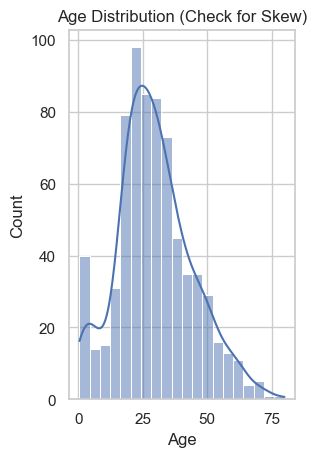

In [97]:
# Histogram for Skewness
plt.subplot(1, 2, 1)
sns.histplot(titanic['Age'], kde=True)
plt.title('Age Distribution (Check for Skew)')
plt.show()

In [98]:
skew_value = titanic['Age'].skew()
print(f"The skewness of Age is: {skew_value:.2f}")

The skewness of Age is: 0.39


Age distribution is slightly right-skewed

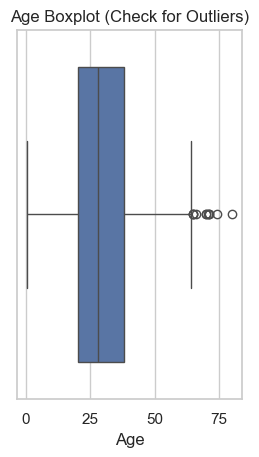

In [99]:
# Boxplot for Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=titanic['Age'])
plt.title('Age Boxplot (Check for Outliers)')
plt.show()

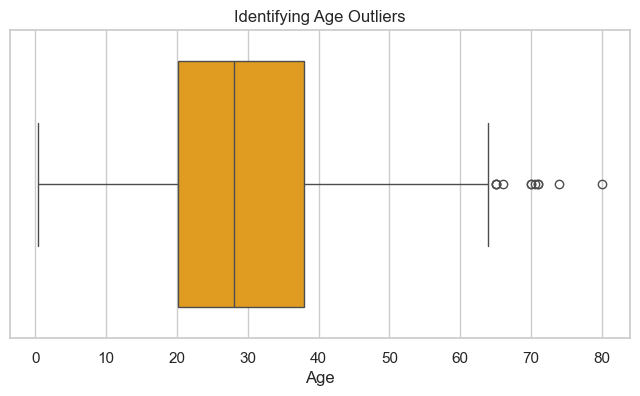

In [100]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=titanic['Age'], color='orange')
plt.title('Identifying Age Outliers')
plt.show()

the Age Column have outliers 

----------------------------------------------------------------------------------------------------------------------------------

## Cleaning Data Set

In [101]:
# Drop the Cabin column because too much data is missing
titanic.drop('Cabin', axis=1, inplace=True)

In [102]:
# Fill missing Embarked values with the most frequent letter
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

In [103]:
# Fill missing Age values with the median
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [104]:
#print mising data
print(titanic.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


--------------------------------------------------------------------------------------------------------------------------------

# Data Visualization

## Univariate Analysis

## Determining the level survival of Passengers

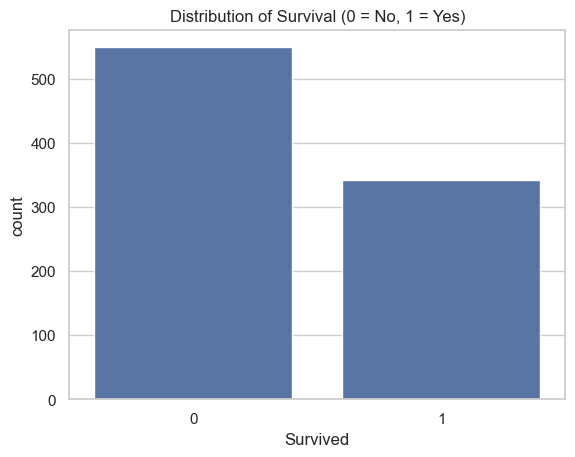

<Figure size 640x480 with 0 Axes>

In [119]:
sns.countplot(x='Survived', data=titanic)
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.show()

plt.savefig('Survival.png', dpi=300)

In [106]:
titanic['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

---------------------------------------------------------------------------------------------------------------------------

# Bivariate Analysis

## Checking if the Age of Passengers have an effect on their survival

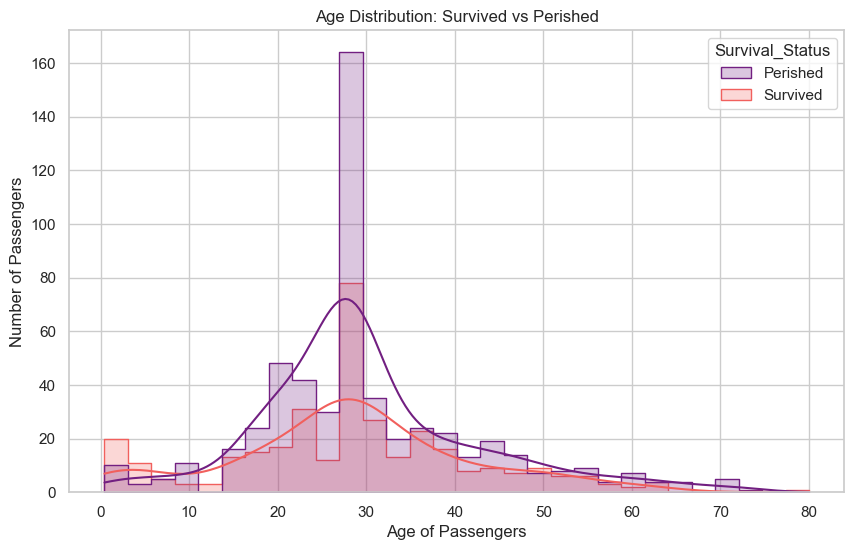

<Figure size 640x480 with 0 Axes>

In [116]:
titanic['Survival_Status'] = titanic['Survived'].map({0: 'Perished', 1: 'Survived'})

plt.figure(figsize=(10, 6))

# Use the new text column for the 'hue'
sns.histplot(data=titanic, x='Age', hue='Survival_Status', kde=True, element="step", palette='magma')

plt.title('Age Distribution: Survived vs Perished')
plt.xlabel('Age of Passengers')
plt.ylabel('Number of Passengers')
plt.show()

plt.savefig('Age_Survival.png', dpi=300)

## Checking if the class of Passengers have an effect on thier survival

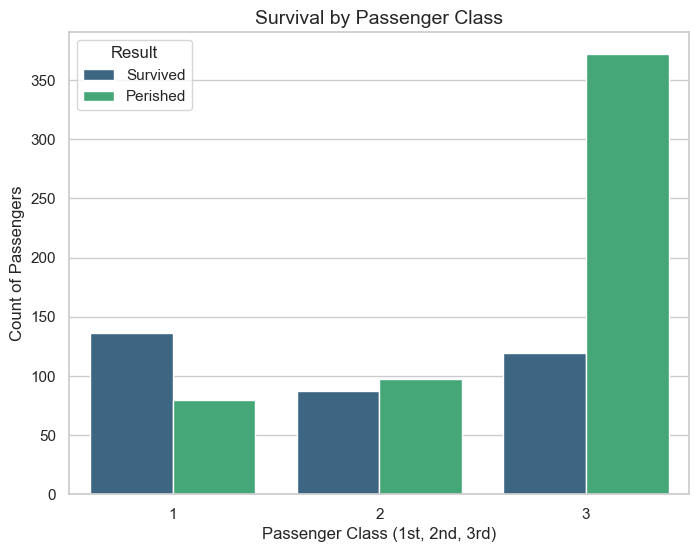

<Figure size 640x480 with 0 Axes>

In [117]:
plt.figure(figsize=(8, 6))

# Create a temporary column for labels if it doesn't exist
temp_df = titanic.copy()
temp_df['Result'] = temp_df['Survived'].map({0: 'Perished', 1: 'Survived'})

# Plotting
sns.countplot(x='Pclass', hue='Result', data=temp_df, palette='viridis')

# Adding labels
plt.title('Survival by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class (1st, 2nd, 3rd)', fontsize=12)
plt.ylabel('Count of Passengers', fontsize=12)

plt.show()

plt.savefig('Class_Survival.png', dpi=300)


## Checking if the Gender of Passengers have an effect on thier survival

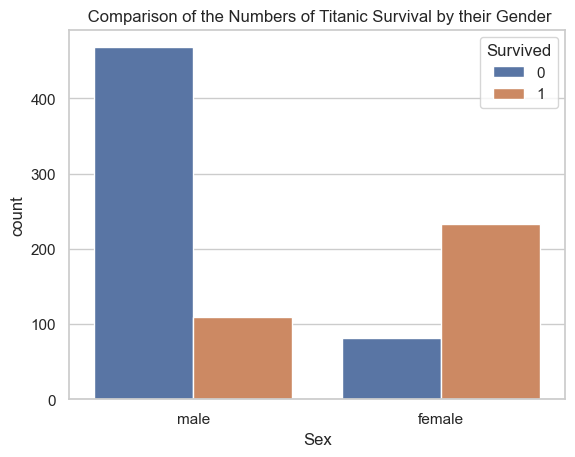

<Figure size 640x480 with 0 Axes>

In [118]:
sns.countplot(x='Sex', hue='Survived', data=titanic)
plt.title(' Comparison of the Numbers of Titanic Survival by their Gender')
plt.show()
plt.savefig('gender_survival.png', dpi=300)

In [110]:
print(titanic.groupby('Sex')['Survived'].mean() * 100)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


## finding the correlation

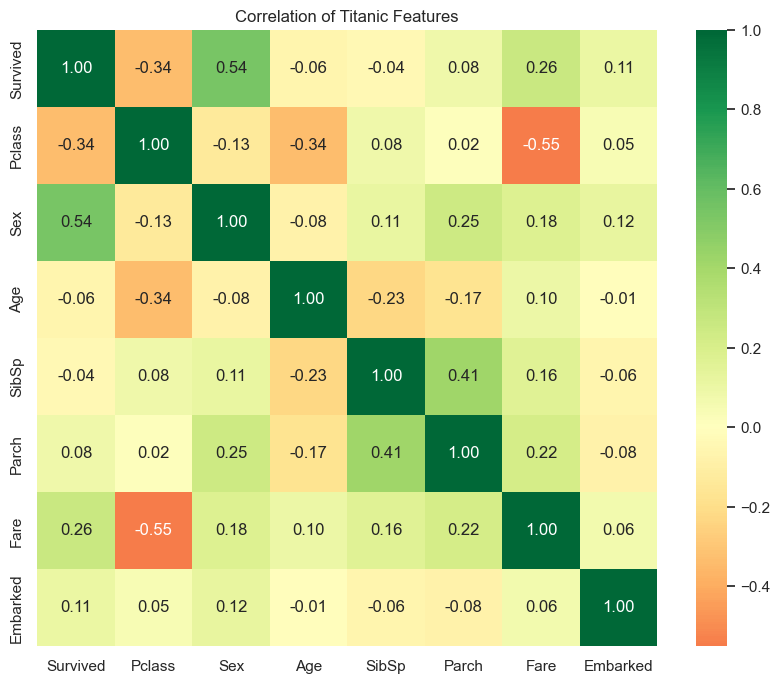

In [111]:
# Create the heatmap copy
heatmap_data = titanic.copy()

# CONVERT Sex and Embarked to numbers (Encoding)
# We use 1 for Female because "Higher Sex Value = Higher Survival" makes the correlation positive
heatmap_data['Sex'] = heatmap_data['Sex'].map({'male': 0, 'female': 1})
heatmap_data['Embarked'] = heatmap_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

#  Select columns and calculate correlation
cols_to_use = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
corr_matrix = heatmap_data[cols_to_use].corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Correlation of Titanic Features')
plt.show()

---------------------------------------------------------------------------------------------------------------------------------

## Observation/Findings

A.) 61.6% of passenagers from the titanic disaster parished while only 38.4% passenagers survived 

B.)  The Titanic Passengers between the ages of 0-10year had a significantly higher survival rate while The highest concentration of fatalities occurred in the 20-35 age range.

C.) The high death rate in the 20-35 age group is directly linked to Class. Third-class passengers in this age bracket represent the largest peak of fatalities, while First-class passengers of the same age had much higher survival odds.

D.) 74.2% of Female Passagers survived  and 18.9% Male passengers survived.

E.)The correlation heatmap identifies Sex (0.54) and Pclass (-0.34) as the two most significant predictors of survival. While Age showed specific patterns in the 'Children Hump', its overall linear correlation is weaker, suggesting that socio-economic status and gender were the primary drivers of survival

# Conculsion

In [112]:
plt.savefig('titanic_heatmap.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In conculsion, the ideal determinate for survival on the Titanic was a female passenger in First Class. Conversely, the group most at risk was males in Third Class. These findings highlight that survival was not random but was systematically dictated by gender, wealth and safety protocols.

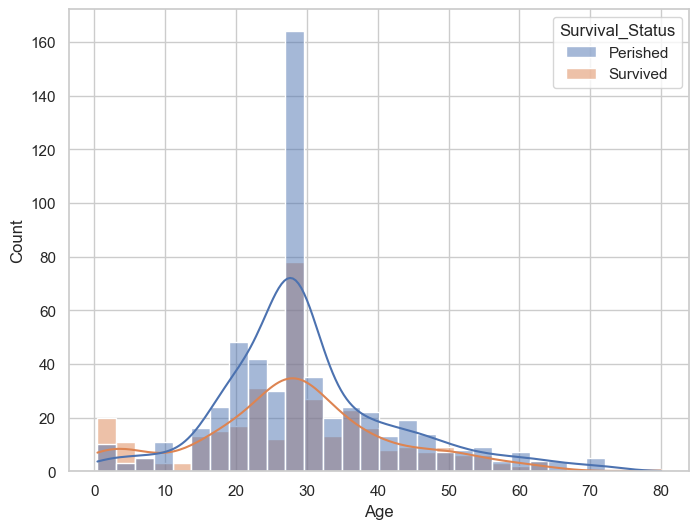

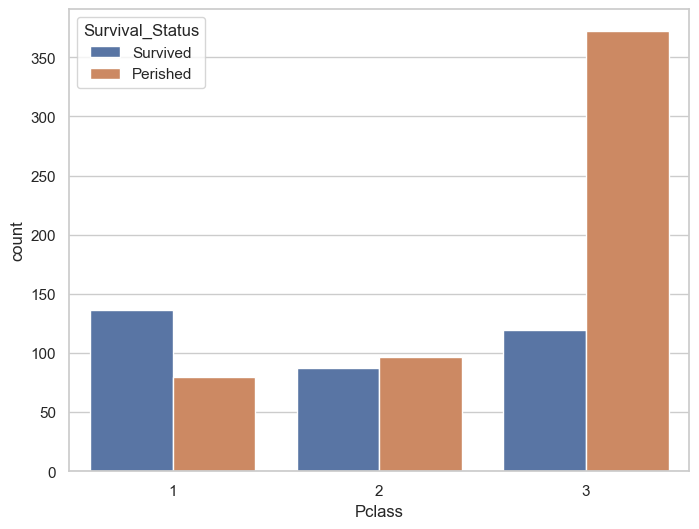

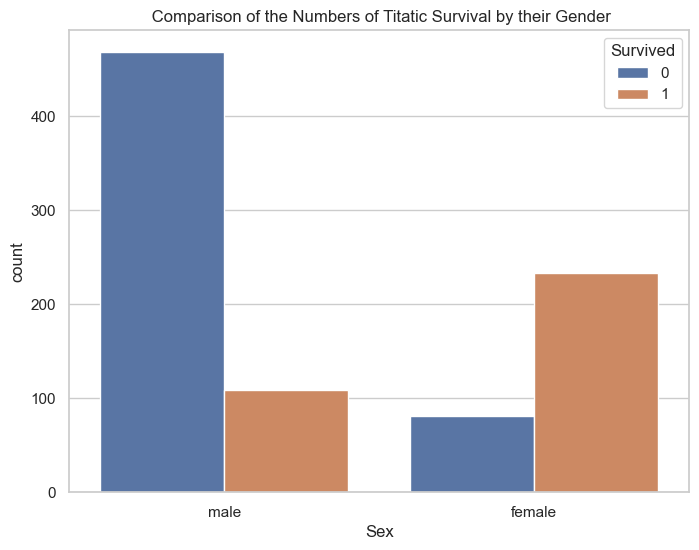

In [114]:
# Save the Age Plot
plt.figure(figsize=(8,6))
sns.histplot(data=titanic, x='Age', hue='Survival_Status', kde=True)
plt.savefig('1_Age_Survival.png', dpi=300)

# Save the Class Plot
plt.figure(figsize=(8,6))
sns.countplot(x='Pclass', hue='Survival_Status', data=titanic)
plt.savefig('2_Class_Survival.png', dpi=300)

# Save the Heatmap
plt.figure(figsize=(8,6))
sns.countplot(x='Sex', hue='Survived', data=titanic)
plt.title(' Comparison of the Numbers of Titatic Survival by their Gender')
plt.savefig('gender.png', dpi=300)